# Annual Shoot Segmentation and Physiological Age Classification from TLS Data — minimal hands-on reproduction

**Paper:** B. Lecigne, S. Delagrange & O. Taugourdeau (2021),
*Annual Shoot Segmentation and Physiological Age Classification from TLS Data in Trees with Acrotonic
Growth*, Forests 12(4):391. [DOI 10.3390/f12040391](https://doi.org/10.3390/f12040391) (CC-BY 4.0).

**Author code:** the `aRchi` R package
([umr-amap/aRchi](https://github.com/umr-amap/aRchi), pinned commit `6a666764b22f`).
**Sample:** `Tree_2.aRchi` tree skeleton (QSM), bundled with the package in `inst/extdata`.

**Scope:** one tree only. We run the **authors' own documented package example** verbatim: read the
skeleton, smooth it, segment annual shoots (AS) with `segment_annual_shoots(tree_age = 13)`, and
classify physiological ages (PA) with `add_physiological_ages()` (thresholds `th = c(0.1, 0.2, 0.5)`).
This is a *partial* demonstration of the paper's method on a single sample — **not** a reproduction of
the paper's dataset-level accuracy figures (90% AS year / 99% PA on perfect data).

**Status:** validated on a fresh Colab **CPU** runtime (outputs below are from that run).
**Runtime:** CPU only — the method is pure R (hierarchical clustering + `data.table`); it has no GPU
code path.

**Note:** this notebook is an original Colab adaptation using the authors' published R package; the
analysis cells run the authors' own example code unmodified. Python is only the launcher for `Rscript`.

日本語の要約: このノートブックは、著者自身の R パッケージ `aRchi` の公式サンプルコード
（`Tree_2.aRchi` スケルトン → `smooth_skeleton` → `segment_annual_shoots(tree_age=13)` →
`add_physiological_ages`）を Colab CPU ランタイムでそのまま実行する最小限の再現デモです。
単一サンプルの部分デモであり、論文のデータセット精度の再現ではありません。Python は R の起動器に過ぎません。

## 0. Runtime selection

Select **Runtime → Change runtime type → CPU** in Colab. A CPU runtime is sufficient and recommended:
the algorithm uses hierarchical clustering and data-table operations on one tree skeleton, which runs
in minutes on CPU. No GPU is used anywhere in the method.

日本語: ランタイムは **CPU を選択**してください。GPU は不要です（手法は純粋な R のクラスタリング＋data.table 処理です）。

**Expected duration** (measured on a fresh Colab CPU VM, 2026-10-09): apt + R dependency binaries
≈ 5–8 min, `aRchi` build from the pinned commit ≈ 2–5 min, example run ≈ 1–3 min. Total ≲ 20 min,
≈ 600–900 MB of downloads. Free-tier time and availability may differ.

## 1. Environment setup

The `aRchi` package declares heavy R imports (`lidR`, `rgl`, `Rfast`, `VoxR`, …). Their precompiled
Linux binaries need a few runtime system libraries (GDAL, GEOS, PROJ, UDUNITS, OpenGL). We install only
the runtime libraries via `apt`. Expected result: a short apt log ending with `system libraries ready`.

日本語: `aRchi` の依存 R パッケージ（バイナリ版）に必要なシステムライブラリ（GDAL 等）を apt で導入します。

In [ ]:
import subprocess

cmd = ("apt-get update -qq && "
       "DEBIAN_FRONTEND=noninteractive apt-get install -y -qq "
       "libgdal34 libgeos-c1v5 libproj25 libudunits2-0 libglu1-mesa "
       "libgl1 libglx0 libegl1 libopengl0 2>&1 | tail -3")
proc = subprocess.run(["bash", "-lc", cmd], text=True, capture_output=True, timeout=1200)
print(proc.stdout[-1500:])
if proc.returncode != 0:
    raise RuntimeError(f"apt system-library install failed (rc={proc.returncode})")
print("system libraries ready")


/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link


system libraries ready


## 2. R dependencies

We install the `aRchi` dependency stack from the **Posit Public Package Manager (p3m.dev) binary
repository for Ubuntu noble**, pinned by the exact URL, using R's official installer (no third-party
scripts). The `HTTPUserAgent` option is required so the repository serves Linux *binary* packages.
Note: the legacy domain `packagemanager.posit.dev` no longer resolves (verified 2026-10-09 from the
Colab VM and from the host); the current P3M host is `p3m.dev`.

Expected result: `All aRchi dependencies installed.` (≈5–8 min)

日本語: 依存 R パッケージを p3m.dev の Ubuntu noble 向けバイナリリポジトリから導入します。

In [ ]:
import subprocess, pathlib, time

def run_r(script: str, name: str, timeout: int = 3600) -> str:
    """Write an R script to /content and run it with Rscript (Python is only the launcher)."""
    path = pathlib.Path("/content") / name
    path.write_text(script)
    t0 = time.time()
    proc = subprocess.run(["Rscript", str(path)], text=True, capture_output=True, timeout=timeout)
    print(proc.stdout[-6000:])
    if proc.stderr:
        print("STDERR:", proc.stderr[-2000:])
    if proc.returncode != 0:
        raise RuntimeError(f"{name} failed with return code {proc.returncode}")
    print(f"[{name} completed in {time.time()-t0:.1f}s]")
    return path

run_r(r"""
options(HTTPUserAgent = sprintf('R/%s R (%s)', getRversion(),
        paste(getRversion(), R.version['platform'], R.version['arch'], R.version['os'])))
repos <- c(P3M='https://p3m.dev/cran/__linux__/noble/latest')
deps <- c('data.table','dplyr','plyr','rgl','lidR','FNN','DiceKriging','stringr','progress',
          'gtools','Rfast','VoxR','fastcluster','pracma','pkgcond','R.matlab','svMisc',
          'circular','Rcpp','RcppArmadillo','RcppProgress','remotes')
install.packages(deps, repos = repos)
ok <- sapply(deps, requireNamespace, quietly=TRUE)
if (any(!ok)) stop('Missing R dependencies: ', paste(names(ok)[!ok], collapse=', '))
cat('All aRchi dependencies installed.\n')
""", "r_install_deps.R", timeout=5400)

All aRchi dependencies installed.

STDERR: ary* package ‘plyr’ ...
* package ‘plyr’ successfully unpacked and SHA256 sums checked
* DONE (plyr)
* installing *binary* package ‘pkgcond’ ...
* package ‘pkgcond’ successfully unpacked and SHA256 sums checked
* DONE (pkgcond)
* installing *binary* package ‘circular’ ...
* package ‘circular’ successfully unpacked and SHA256 sums checked
* DONE (circular)
* installing *binary* package ‘RcppArmadillo’ ...
* package ‘RcppArmadillo’ successfully unpacked and SHA256 sums checked
* DONE (RcppArmadillo)
* installing *binary* package ‘classInt’ ...
* package ‘classInt’ successfully unpacked and SHA256 sums checked
* DONE (classInt)
* installing *binary* package ‘geometry’ ...
* package ‘geometry’ successfully unpacked and SHA256 sums checked
* DONE (geometry)
* installing *binary* package ‘raster’ ...
* package ‘raster’ successfully unpacked and SHA256 sums checked
* DONE (raster)
* installing *binary* package ‘R.utils’ ...
* package ‘R.utils’ succes

PosixPath('/content/r_install_deps.R')

## 3. Install the authors' `aRchi` package (pinned revision)

We build `aRchi` from the authors' GitHub repository at the pinned commit `6a666764b22ff737bbd4fbf736c7979ec398c4f0` (dev version 2.1.4)
with `remotes::install_github(ref=...)`. If the pinned build is unavailable the cell fails explicitly
rather than silently substituting a different implementation.

Expected result: `aRchi installed: TRUE` plus the package version. (≈2–5 min)

日本語: 著者の GitHub リポジトリをピン留めしたコミットから `aRchi` をビルドします（Rcpp のコンパイル数分）。

In [ ]:
run_r(r"""
options(HTTPUserAgent = sprintf('R/%s R (%s)', getRversion(),
        paste(getRversion(), R.version['platform'], R.version['arch'], R.version['os'])))
repos <- c(P3M='https://p3m.dev/cran/__linux__/noble/latest')
t0 <- Sys.time()
Sys.setenv(R_REMOTES_UPGRADE = 'never')
remotes::install_github('umr-amap/aRchi',
                        ref = '6a666764b22ff737bbd4fbf736c7979ec398c4f0',
                        repos = repos, dependencies = FALSE,
                        build_vignettes = FALSE, upgrade = 'never')
cat('BUILD_MIN:', round(as.numeric(difftime(Sys.time(), t0, units='mins')), 2), '\n')
cat('aRchi installed:', requireNamespace('aRchi', quietly=TRUE), '\n')
if (requireNamespace('aRchi', quietly=TRUE)) cat('aRchi version:', as.character(packageVersion('aRchi')), '\n')
""", "r_install_archi.R", timeout=5400)

── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmpc7qpYi/remotesc94db7d0a2/umr-amap-aRchi-6a66676/DESCRIPTION’ ... OK
* preparing ‘aRchi’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘aRchi_2.1.4.tar.gz’

x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG  -I'/usr/local/lib/R/site-library/Rcpp/include' -I'/usr/local/lib/R/site-library/RcppArmadillo/include' -I'/usr/local/lib/R/site-library/RcppProgress/include'     -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c RcppExports.cp

PosixPath('/content/r_install_archi.R')

## 4. Acquire and verify the sample skeleton

The sample `Tree_2.aRchi` ships **inside the installed package** (`inst/extdata`). We verify its bytes
before use: exact size (784,308 bytes) and the Git blob SHA-1 recorded from the authors' repository
tree at the pinned commit (`3826ae66ef63…`).

Expected result: `git-blob-sha: 3826ae66ef6354a6016836036c4e6ca49561e884` — the same file the authors ship on GitHub.

日本語: サンプル `Tree_2.aRchi` はパッケージに同梱されています。サイズと Git blob SHA-1 を検証し、
著者のリポジトリ（ピン留めコミット）の同一ファイルであることを確認します。

In [ ]:
run_r(r"""
suppressMessages(library(aRchi))
f <- system.file('extdata','Tree_2.aRchi', package='aRchi')
cat('sample_path:', f, '\n')
cat('sample_size:', file.size(f), '\n')
raw <- readBin(f, 'raw', n = file.size(f))
blob <- paste0(as.character(openssl::sha1(c(charToRaw(sprintf('blob %d', file.size(f))), as.raw(0), raw))), collapse='')
cat('git-blob-sha:', blob, '\n')
stopifnot(file.size(f) == 784308)
if (blob != '3826ae66ef6354a6016836036c4e6ca49561e884') stop('Sample blob SHA does not match the pinned repository tree!')
cat('sample verified against pinned commit.\n')
""", "r_verify_sample.R", timeout=600)

sample_path: /usr/local/lib/R/site-library/aRchi/extdata/Tree_2.aRchi 
sample_size: 784308 
git-blob-sha: 3826ae66ef6354a6016836036c4e6ca49561e884 
sample verified against pinned commit.

[r_verify_sample.R completed in 12.8s]


PosixPath('/content/r_verify_sample.R')

## 5. Preview the input: the Tree_2 skeleton (before analysis)

Before the method, we inspect the raw input. The `.aRchi` file is an RDS object of the authors' S4
`aRchi` class; its `QSM` slot is a `data.table` of tree cylinders (`startX/startY/startZ`,
`endX/endY/endZ`, radii, `axis_ID`, …). We export that table and render a static projection of the
skeleton — an input view, not a result.

Expected result: printed cylinder count, column names, axis count, height range, and a PNG projection
of the unsegmented skeleton.

日本語: 解析前の入力（Tree_2 のスケルトン＝円柱テーブル）を確認し、静的に描画します。

cylinders: 1990 
columns: startX, startY, startZ, endX, endY, endZ, cyl_ID, parent_ID, extension_ID, radius_cyl, length, volume, axis_ID, segment_ID, node_ID, branching_order 
axes: 276 

[r_export_input.R completed in 8.7s]


   cyl_ID  axis_ID   startX  startY  startZ   endZ
0       1        1  1.46005  1.2497   0.003  0.092
1       2        1  1.45994  1.2360   0.092  0.167
2       3        1  1.47226  1.2350   0.167  0.245
3       4        1  1.47568  1.2277   0.245  0.319
4       5        1  1.47858  1.2416   0.319  0.389
height range (m): 0.0 - 6.18


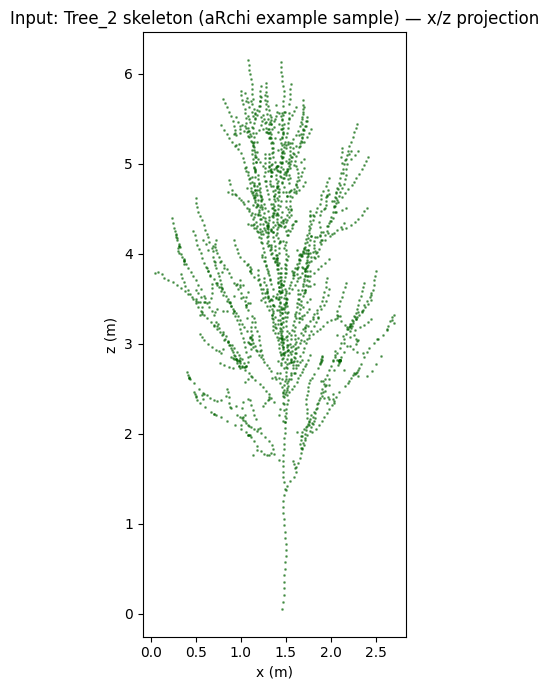

In [ ]:
run_r(r"""
suppressMessages(library(aRchi))
f <- system.file('extdata','Tree_2.aRchi', package='aRchi')
aRchi <- aRchi::read_aRchi(f)
qsm <- aRchi@QSM
cat('cylinders:', nrow(qsm), '\n')
cat('columns:', paste(names(qsm), collapse=', '), '\n')
cat('axes:', length(unique(qsm$axis_ID)), '\n')
write.csv(qsm, '/content/qsm_input.csv', row.names=FALSE)
""", "r_export_input.R", timeout=900)

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/qsm_input.csv")
print(df[["cyl_ID", "axis_ID", "startX", "startY", "startZ", "endZ"]].head(5))
print("height range (m):", round(df.startZ.min(), 2), "-", round(df.endZ.max(), 2))
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter((df.startX + df.endX) / 2, (df.startZ + df.endZ) / 2, s=1, c="darkgreen", alpha=0.5)
ax.set_title("Input: Tree_2 skeleton (aRchi example sample) — x/z projection")
ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 6. Core method: the authors' example, verbatim

This cell runs the exact example from the authors' documentation (`R/add_physiological_ages.R` lines
17–33 and `R/segment_annual_shoots.R` lines 27–40 at the pinned commit): `smooth_skeleton()`, then
`segment_annual_shoots(aRchi, tree_age = 13)` — AS = 1 is the last growing season — then
`add_physiological_ages()` with its defaults (`th = c(0.1, 0.2, 0.5)`, `correct_PA = TRUE`).
`tree_age = 13` is the value the authors themselves use for this sample. The only difference from the
authors' snippet is that we skip their interactive `rgl` 3D window (headless Colab) and visualize
statically in the next section.

Expected result: printed cylinder/axis counts, AS and PA class tables, and an exported CSV.

日本語: 著者のサンプルコードをそのまま実行します（`rgl` の対話プロットのみヘッドレス用に静的描画へ置換）。

In [ ]:
run_r(r"""
suppressMessages(library(aRchi))
f <- system.file('extdata','Tree_2.aRchi', package='aRchi')
aRchi <- aRchi::read_aRchi(f)                                   # author example, verbatim
aRchi <- smooth_skeleton(aRchi)                                 # author example, verbatim
aRchi <- aRchi::segment_annual_shoots(aRchi, tree_age = 13)     # author example, verbatim
aRchi <- aRchi::add_physiological_ages(aRchi)                   # author example, verbatim
qsm <- aRchi@QSM
cat('cylinders:', nrow(qsm), ' axes:', length(unique(qsm$axis_ID)), '\n')
cat('AS classes:', paste(sort(unique(qsm$AS)), collapse=','), '\n')
cat('PA classes:', paste(sort(unique(qsm$PA)), collapse=','), '\n')
cat('AS counts:\n'); print(table(qsm$AS))
cat('PA counts:\n'); print(table(qsm$PA))
write.csv(qsm, '/content/qsm_result.csv', row.names=FALSE)
cat('csv_bytes:', file.size('/content/qsm_result.csv'), '\n')
""", "r_run_example.R", timeout=3600)

Progress: 1 on 1  cylinders: 2487  axes: 276 
AS classes: 1,2,3,4,5,6,7,8,9,10,11,12,13 
PA classes: 1,2,3,4 
AS counts:

  1   2   3   4   5   6   7   8   9  10  11  12  13 
769 607 392 236 207 102  79  41  18  15   7   8   6 
PA counts:

  1   2   3   4 
302 909 531 745 
csv_bytes: 458796 

[r_run_example.R completed in 28.5s]


PosixPath('/content/r_run_example.R')

## 7. Results: annual shoots and physiological ages on the skeleton

Notebook-created static visualizations of the authors' method output (not author figures): the same
x/z projection as in section 5, now colored by segmented annual shoot (`AS`) and by physiological age
(`PA`; 1 = longest, most specialized axes). The authors' own example would show this in an interactive
`rgl` window via `plot(aRchi, color="physiological_age")`.

Expected result: two PNG panels — AS coloring and PA coloring of the skeleton.

日本語: 結果の可視化（このノートブックで作成した静的図；著者の図ではありません）。AS＝年次シュート番号、PA＝生理的年齢。

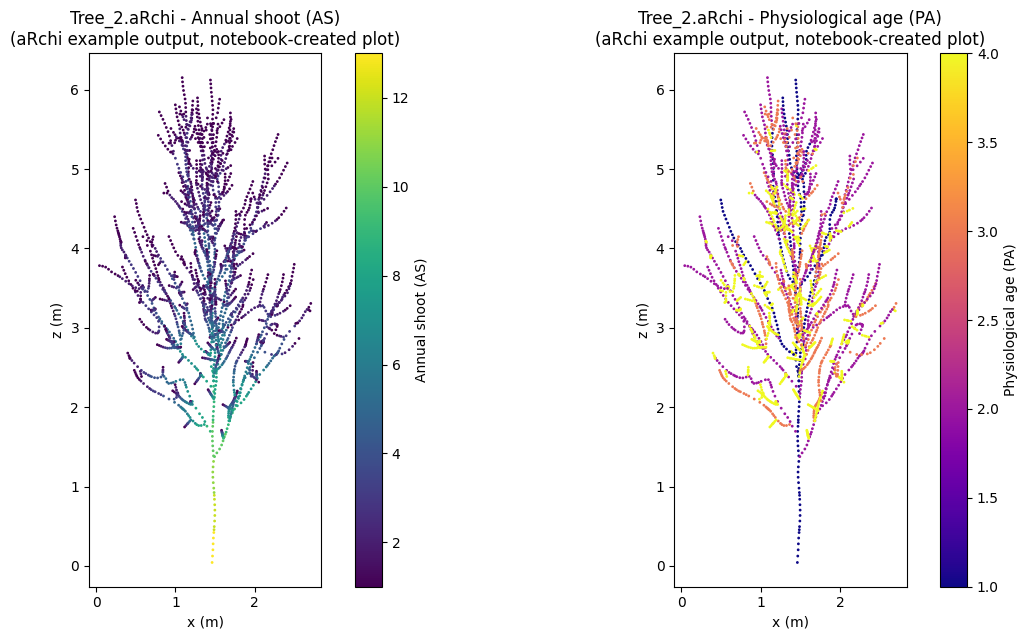

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/qsm_result.csv")
df["midX"] = (df.startX + df.endX) / 2
df["midZ"] = (df.startZ + df.endZ) / 2

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, col, title, cmap in [(axes[0], "AS", "Annual shoot (AS)", "viridis"),
                             (axes[1], "PA", "Physiological age (PA)", "plasma")]:
    s = ax.scatter(df.midX, df.midZ, c=df[col], s=1, cmap=cmap)
    ax.set_title("Tree_2.aRchi - " + title + "\n(aRchi example output, notebook-created plot)")
    ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)"); ax.set_aspect("equal")
    plt.colorbar(s, ax=ax, label=title)
plt.tight_layout(); plt.show()

## 8. Small results table and CSV export

Quantitative summary of the single-sample run: cylinders per physiological age (`PA`; 1 = longest, most
specialized axes per the paper's convention), number of distinct annual shoots per PA, and total
cylinder length. The full cylinder table (`/content/qsm_result.csv`) and per-shoot lengths
(`/content/as_lengths.csv`) are exported for further inspection in Colab.

Expected result: a small DataFrame and export confirmations.

日本語: PA ごとの円柱数・AS 数・全長をまとめた小さな表と CSV 出力。

In [ ]:
import pandas as pd

df = pd.read_csv("/content/qsm_result.csv")
df["length"] = ((df.startX - df.endX)**2 + (df.startY - df.endY)**2 + (df.startZ - df.endZ)**2) ** 0.5

pa_summary = (df.groupby("PA")
                .agg(cylinders=("cyl_ID", "size"),
                     n_annual_shoots=("AS", "nunique"),
                     total_length_m=("length", "sum"))
                .round(2))
display(pa_summary)

as_length = df.groupby(["axis_ID", "AS"])["length"].sum().reset_index()
print("AS length (m): min", round(as_length.length.min(), 3),
      "| median", round(as_length.length.median(), 3),
      "| max", round(as_length.length.max(), 3))
as_length.to_csv("/content/as_lengths.csv", index=False)
print("exported /content/as_lengths.csv and /content/qsm_result.csv")

,cylinders,n_annual_shoots,total_length_m
PA,,,
1,302,13,17.22
2,909,10,48.10
3,531,8,25.97
4,745,9,22.40


AS length (m): min 0.004 | median 0.079 | max 0.821
exported /content/as_lengths.csv and /content/qsm_result.csv


## 9. Interpretation, limitations, references

**What this demonstrates:** the authors' published example runs end-to-end on Colab CPU —
acrotony-based annual-shoot segmentation of the `Tree_2` skeleton and physiological-age classification
by shoot length, with the authors' own parameters (`tree_age = 13`, `th = c(0.1, 0.2, 0.5)`,
`correct_PA = TRUE`).

**What this does not demonstrate:** the paper's accuracy results (90% AS year / 99% PA on perfect data;
TLS-simulation and real-tree validation) are dataset-level analyses not attempted here. The optional
`add_non_reconstructed()` automaton (paper phase "non-reconstructed short axes") was not run. The
sample's `tree_age` and thresholds come from the authors' own package example, not from the paper's
full text (MDPI full text returned HTTP 403 to automated access at investigation time). A single-tree
result says nothing about dataset-level performance.

**Provenance:** paper DOI 10.3390/f12040391 (CC-BY 4.0); code umr-amap/aRchi pinned commit
`6a666764b22ff737bbd4fbf736c7979ec398c4f0` (CeCILL license); sample `Tree_2.aRchi` verified by Git
blob SHA-1 against that commit. PhenoPaper investigation/flow records were used as research guidance
only.

日本語: 本ノートブックは論文手法の最小デモであり、論文の精度評価やデータセット規模の検証は含みません。
パラメータは著者自身のサンプル例から採用しています。